# Feature Extraction Validation
Goal: verify the extracted features (and the new augmentation step) actually look
correct BEFORE spending another training cycle on them.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
 
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
from src.config import (FEATURES_CSV, FEATURES_NPY, get_actor_splits, EMOTION_MAP,)
 
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load features and check shape alignment

In [3]:
if not os.path.exists(FEATURES_CSV) or not os.path.exists(FEATURES_NPY):
    raise FileNotFoundError("Run src/feature_extraction.py first to generate these files.")
 
flat_df = pd.read_csv(FEATURES_CSV)
sequences = np.load(FEATURES_NPY)
 
print(f"features.csv shape: {flat_df.shape}")
print(f"features.npy shape: {sequences.shape}")
assert len(flat_df) == len(sequences), "MISMATCH: csv rows != npy entries — re-run feature_extraction.py"
print("Row counts match.")
 
flat_df.head()

features.csv shape: (6240, 118)
features.npy shape: (6240, 128, 173)
Row counts match.


,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,mfcc3_std,mfcc4_mean,mfcc4_std,mfcc5_mean,mfcc5_std,...,spectral_contrast_mean,spectral_contrast_std,rms_mean,rms_std,filename,emotion,actor_id,gender,is_augmented,augmentation_type
0,-733.149170,180.447266,41.891106,67.638367,-3.003401,13.225677,8.284048,19.944967,4.752473,15.820820,...,18.155483,7.607892,0.001848,0.003119,03-01-01-01-01-01-01.wav,neutral,1,male,False,none
1,-749.408142,169.001266,45.725307,70.443398,-4.755539,13.600594,9.356760,21.074305,3.669523,14.379333,...,19.558125,10.610792,0.001323,0.002310,03-01-01-01-01-01-01_pitch-2.wav,neutral,1,male,True,pitch-2
2,-747.119751,175.048126,40.159416,64.221436,-5.746214,15.452844,9.301963,21.971827,0.457747,13.079771,...,21.030815,6.869947,0.001251,0.002161,03-01-01-01-01-01-01_pitch+2.wav,neutral,1,male,True,pitch+2
3,-737.218750,177.458130,46.025414,68.408203,-4.621752,13.700390,8.885536,21.410522,5.022164,15.994637,...,19.529918,7.603288,0.001427,0.002259,03-01-01-01-01-01-01_stretch0.9.wav,neutral,1,male,True,stretch0.9
4,-761.169250,172.340363,37.298981,63.348171,-2.972145,11.915746,7.661303,18.799105,4.136042,14.974027,...,18.701963,6.942741,0.001227,0.002267,03-01-01-01-01-01-01_stretch1.1.wav,neutral,1,male,True,stretch1.1


## 2. Augmentation sanity check
Confirm augmented rows exist, how many, and what types were generated.

In [4]:
print("is_augmented value counts:")
print(flat_df['is_augmented'].value_counts())
 
print("\naugmentation_type breakdown:")
print(flat_df['augmentation_type'].value_counts())
 
n_original = (~flat_df['is_augmented']).sum()
n_augmented = flat_df['is_augmented'].sum()
print(f"\nOriginal files: {n_original} | Augmented rows: {n_augmented} | "
      f"Multiplier: {(n_original+n_augmented)/n_original:.2f}x")

is_augmented value counts:
is_augmented
True     4800
False    1440
Name: count, dtype: int64

augmentation_type breakdown:
augmentation_type
none          1440
pitch-2        960
pitch+2        960
stretch0.9     960
stretch1.1     960
noise          960
Name: count, dtype: int64

Original files: 1440 | Augmented rows: 4800 | Multiplier: 4.33x


## 3. Leakage check — augmentation must be TRAIN-ACTOR ONLY
This re-verifies (independently of dataset.py's internal assert) that no augmented
row belongs to a val/test actor. If this fails, DO NOT proceed to training — it
means evaluation numbers would be dishonest.


In [5]:
train_actors, val_actors, test_actors = get_actor_splits(flat_df['actor_id'].unique())
 
val_test_actors = set(val_actors) | set(test_actors)
leaked = flat_df[(flat_df['actor_id'].isin(val_test_actors)) & (flat_df['is_augmented'])]
 
print(f"Train actors: {sorted(train_actors)}")
print(f"Val actors:   {sorted(val_actors)}")
print(f"Test actors:  {sorted(test_actors)}")
print(f"\nAugmented rows leaked into val/test: {len(leaked)}  (must be 0)")
 
if len(leaked) == 0:
    print("PASS: no augmentation leakage into val/test.")
else:
    print("FAIL: augmentation leaked into evaluation data — fix before training!")
    display(leaked)

Train actors: [1, 2, 3, 4, 6, 7, 9, 12, 13, 17, 18, 19, 20, 21, 22, 24]
Val actors:   [5, 14]
Test actors:  [8, 10, 11, 15, 16, 23]

Augmented rows leaked into val/test: 0  (must be 0)
PASS: no augmentation leakage into val/test.


## 4. Class balance: before vs after augmentation (train split only)
Confirm augmentation actually helped balance training data across emotions, not just multiplied the existing imbalance.

           before_augmentation  after_augmentation
emotion                                           
calm                       128                 768
happy                      128                 768
sad                        128                 768
angry                      128                 768
fearful                    128                 768
disgust                    128                 768
surprised                  128                 768
neutral                     64                 384


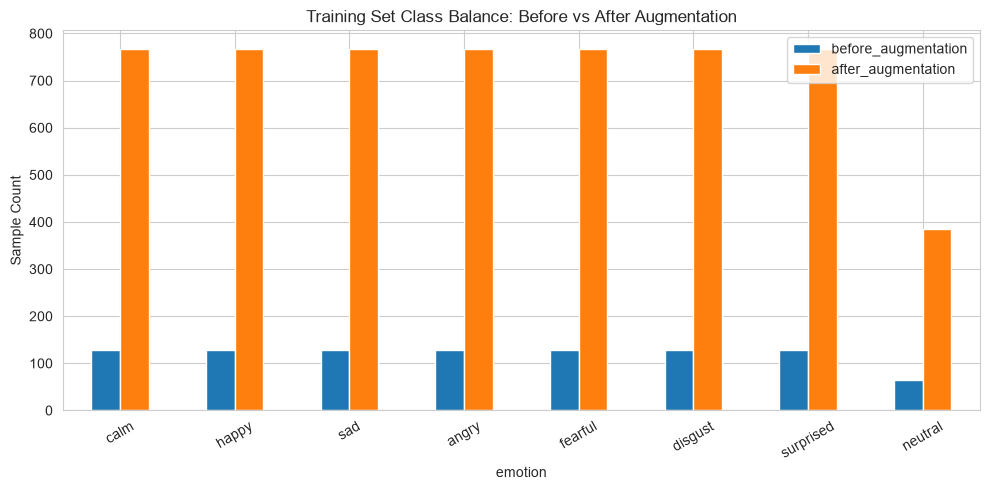

In [6]:
train_df = flat_df[flat_df['actor_id'].isin(train_actors)]
 
original_counts = train_df[~train_df['is_augmented']]['emotion'].value_counts()
augmented_counts = train_df['emotion'].value_counts()  # includes augmented
 
compare_df = pd.DataFrame({'before_augmentation': original_counts, 'after_augmentation': augmented_counts}).fillna(0)
print(compare_df)
 
compare_df.plot(kind='bar', figsize=(10, 5))
plt.title('Training Set Class Balance: Before vs After Augmentation')
plt.ylabel('Sample Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Visual check: original vs augmented spectrograms for the SAME clip

In [7]:
sample_original = train_df[~train_df['is_augmented']].iloc[0]
base_filename_prefix = sample_original['filename'].replace('.wav', '')
 
variant_rows = train_df[train_df['filename'].str.startswith(base_filename_prefix)]
print(f"Found {len(variant_rows)} versions (original + augmented) of: {sample_original['filename']}")
variant_rows[['filename', 'is_augmented', 'augmentation_type']]

Found 6 versions (original + augmented) of: 03-01-01-01-01-01-01.wav


,filename,is_augmented,augmentation_type
0,03-01-01-01-01-01-01.wav,False,none
1,03-01-01-01-01-01-01_pitch-2.wav,True,pitch-2
2,03-01-01-01-01-01-01_pitch+2.wav,True,pitch+2
3,03-01-01-01-01-01-01_stretch0.9.wav,True,stretch0.9
4,03-01-01-01-01-01-01_stretch1.1.wav,True,stretch1.1
5,03-01-01-01-01-01-01_noise.wav,True,noise


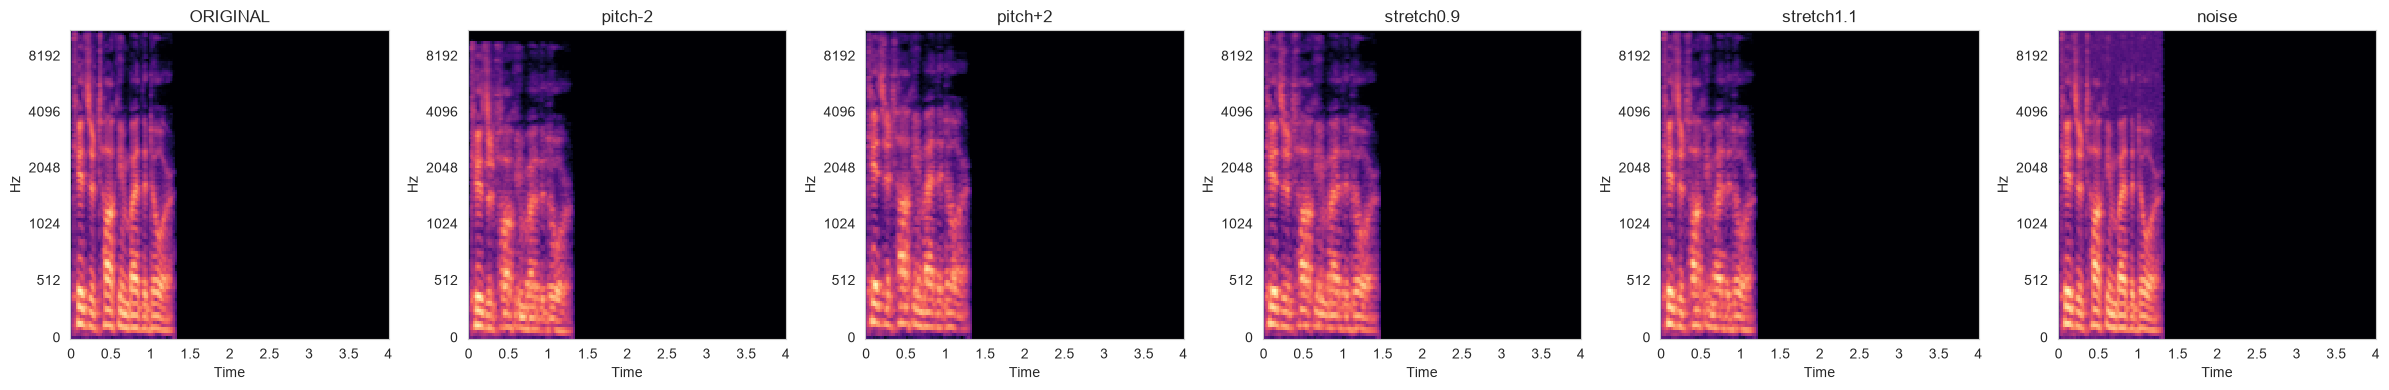

In [8]:
n_variants = len(variant_rows)
fig, axes = plt.subplots(1, n_variants, figsize=(4*n_variants, 4))
if n_variants == 1:
    axes = [axes]
 
for ax, (idx, row) in zip(axes, variant_rows.iterrows()):
    mel_db = sequences[idx]
    img = librosa.display.specshow(mel_db, x_axis='time', y_axis='mel', ax=ax)
    label = row['augmentation_type'] if row['is_augmented'] else 'ORIGINAL'
    ax.set_title(label)
 
plt.tight_layout()
plt.show()

## 6. Feature distribution check: original vs augmented MFCCs

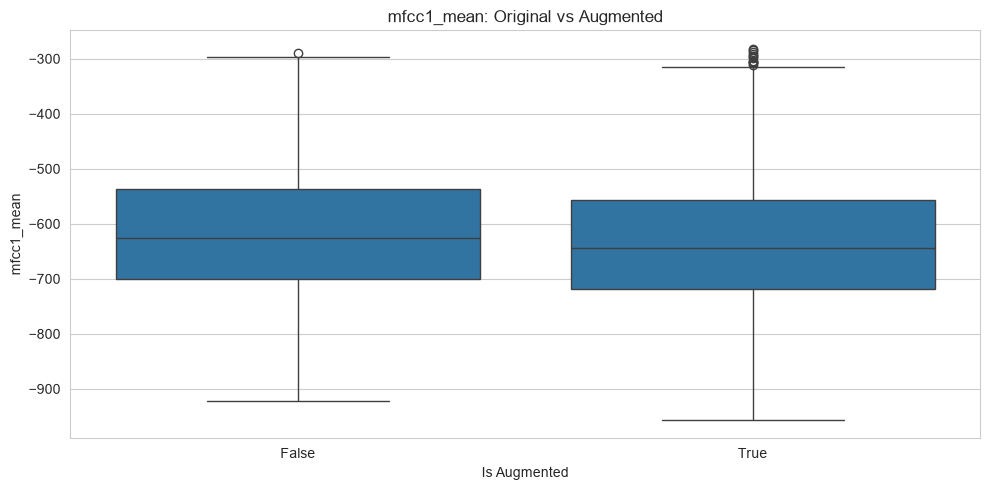

               count        mean         std         min         25%  \
is_augmented                                                           
False          960.0 -616.875161  114.762664 -921.992065 -700.174667   
True          4800.0 -633.848867  116.248250 -955.937317 -717.794056   

                    50%         75%         max  
is_augmented                                     
False        -625.31250 -537.593185 -289.926300  
True         -643.42215 -556.522995 -282.281292  


In [9]:
mfcc1_mean_col = 'mfcc1_mean'  # first MFCC coefficient's mean, one of the extracted flat features
 
plt.figure()
sns.boxplot(data=train_df, x='is_augmented', y=mfcc1_mean_col)
plt.title(f'{mfcc1_mean_col}: Original vs Augmented')
plt.xlabel('Is Augmented')
plt.tight_layout()
plt.show()
 
print(train_df.groupby('is_augmented')[mfcc1_mean_col].describe())

## 7. Class separability check: PCA and t-SNE on flat features

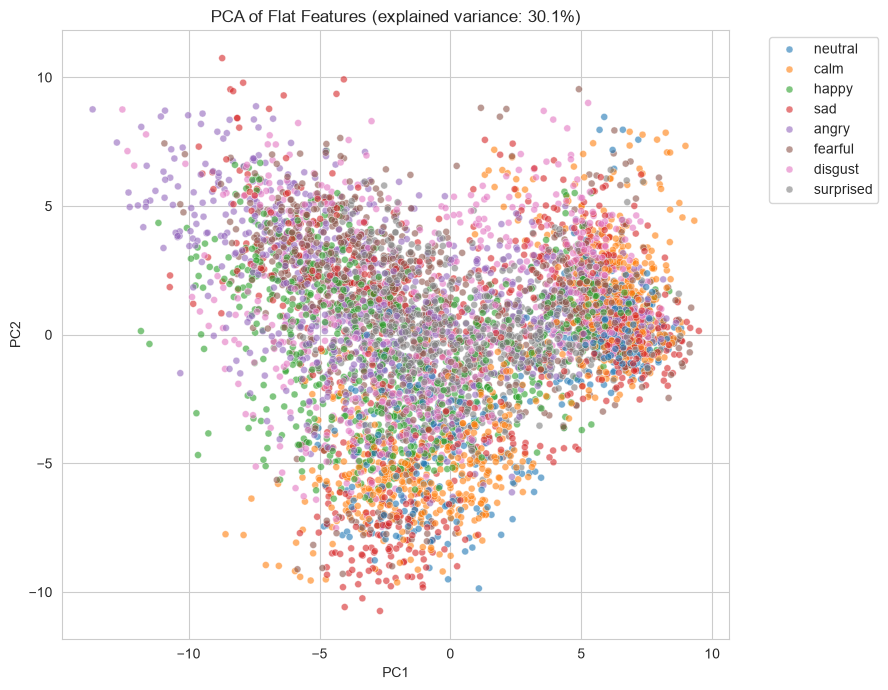

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
 
feature_cols = [c for c in flat_df.columns if c.endswith('_mean') or c.endswith('_std')]
X = train_df[feature_cols].fillna(0).values
y = train_df['emotion'].values
 
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
 
plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', alpha=0.6, s=25)
plt.title(f'PCA of Flat Features (explained variance: {pca.explained_variance_ratio_.sum():.1%})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

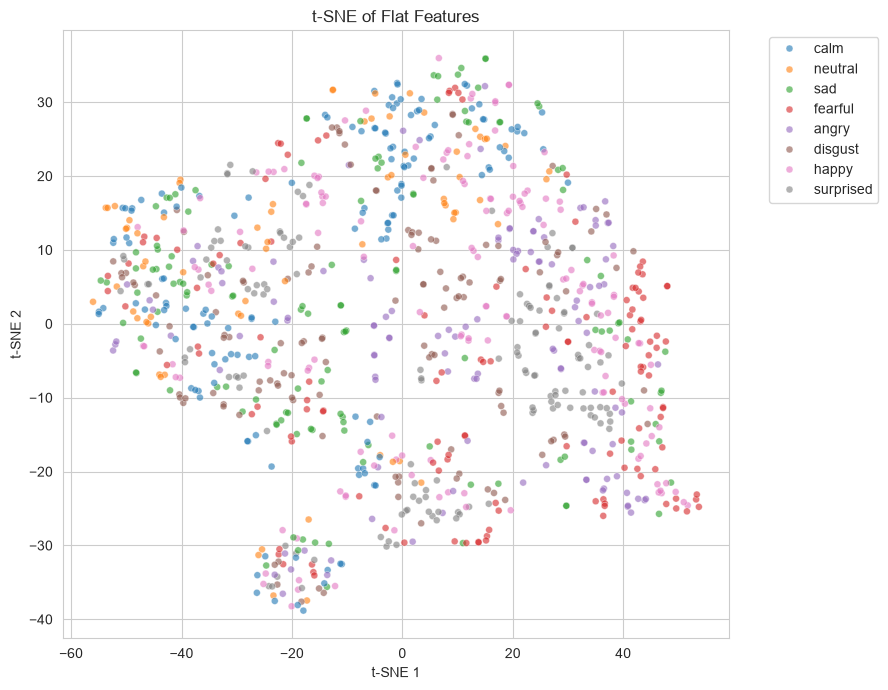

In [11]:
from sklearn.manifold import TSNE
 
# t-SNE is slower — subsample if the training set is large
sample_size = min(1000, len(X_scaled))
sample_idx = np.random.RandomState(42).choice(len(X_scaled), sample_size, replace=False)
 
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled[sample_idx])
 
plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y[sample_idx], palette='tab10', alpha=0.6, s=25)
plt.title('t-SNE of Flat Features')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()